In [20]:
import statsmodels.api as sm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

In [21]:
df_ml = pd.read_csv('../data/cleaned_train_listing_ml.csv')
df_cleaned = pd.read_csv('../data/cleaned_listing.csv')
df_cleaned_test = pd.read_csv('../data/cleaned_test_listing_ml.csv')

In [22]:
df_ml.dtypes

host_is_superhost                                      int64
neighbourhood_cleansed                                 int64
latitude                                             float64
longitude                                            float64
property_type                                          int64
accommodates                                           int64
bathrooms                                            float64
bedrooms                                             float64
beds                                                 float64
price                                                float64
minimum_nights                                         int64
price_log                                            float64
availability_365                                       int64
instant_bookable                                       int64
room_type_Entire home/apt                               bool
room_type_Hotel room                                    bool
room_type_Private room  

In [23]:
df_cleaned.columns

Index(['host_is_superhost', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms',
       'beds', 'price', 'minimum_nights', 'availability_365',
       'instant_bookable', 'price_per_night'],
      dtype='object')

In [24]:
# Fit your OLS model
X = df_ml.drop(columns=["price_log", "price"])
X = X.astype(float)
y = df_ml['price']

model = sm.OLS(y, X).fit()

# Get influence measures
influence = model.get_influence()
cooks_d = influence.cooks_distance[0]  # array of Cook's D values
p_values = influence.cooks_distance[1]  # associated p-values (rarely used)

# Attach back to dataframe
df_ml['cooks_d'] = cooks_d

In [25]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.290
Model:                            OLS   Adj. R-squared:                  0.289
Method:                 Least Squares   F-statistic:                     709.9
Date:                Mon, 17 Aug 2026   Prob (F-statistic):               0.00
Time:                        02:29:22   Log-Likelihood:            -2.2912e+05
No. Observations:               29624   AIC:                         4.583e+05
Df Residuals:                   29606   BIC:                         4.584e+05
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                                        coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------

In [26]:
df_ml.sort_values(by = 'cooks_d').tail(20)

,host_is_superhost,neighbourhood_cleansed,latitude,longitude,property_type,accommodates,bathrooms,bedrooms,beds,price,...,availability_365,instant_bookable,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room,neighbourhood_group_cleansed_City of Los Angeles,neighbourhood_group_cleansed_Other Cities,neighbourhood_group_cleansed_Unincorporated Areas,cooks_d
4902,0,25,34.092680,-118.413940,26,14,8.5,6.0,6.0,12500.0,...,364,0,True,False,False,False,False,True,False,0.027531
4774,0,136,34.045159,-118.661567,17,12,8.0,6.0,6.0,15000.0,...,269,0,True,False,False,False,False,True,False,0.038001
24890,0,19,34.077770,-118.452580,17,11,11.0,10.0,14.0,10000.0,...,365,1,True,False,False,False,True,False,False,0.042450
9210,0,194,34.020910,-118.494210,67,2,1.0,1.0,1.0,17940.0,...,4,1,False,False,True,False,False,True,False,0.044315
10772,0,19,34.086040,-118.463100,26,16,24.0,12.0,10.0,10000.0,...,179,1,True,False,False,False,True,False,False,0.045007
16337,0,136,34.039039,-118.668867,17,16,16.0,16.0,16.0,10000.0,...,269,0,True,False,False,False,False,True,False,0.048692
20719,0,194,34.020810,-118.494310,67,4,1.0,1.0,2.0,19117.0,...,8,1,False,False,True,False,False,True,False,0.054424
4110,0,194,34.020630,-118.494130,67,2,1.0,1.0,1.0,20343.0,...,4,1,False,False,True,False,False,True,False,0.057177
3260,0,30,34.186870,-118.304620,88,1,1.0,0.0,1.0,10000.0,...,89,0,True,False,False,False,False,True,False,0.062464
13288,0,143,34.041100,-118.343380,17,16,21.0,24.0,32.0,1900.0,...,365,0,True,False,False,False,True,False,False,0.067483


In [27]:
df_ml['cooks_d'].describe()

count    2.962400e+04
mean     1.002611e-04
std      2.636935e-03
min      7.528399e-17
25%      1.173748e-07
50%      6.920003e-07
75%      3.213367e-06
max      2.090082e-01
Name: cooks_d, dtype: float64

Now, we need to choose a threshold for this

1. cook's way: above 1, none here
2. hardin, hilbe: distance should be < 4/N
3. common sense: look at the relation distances (use scatterplot to view)

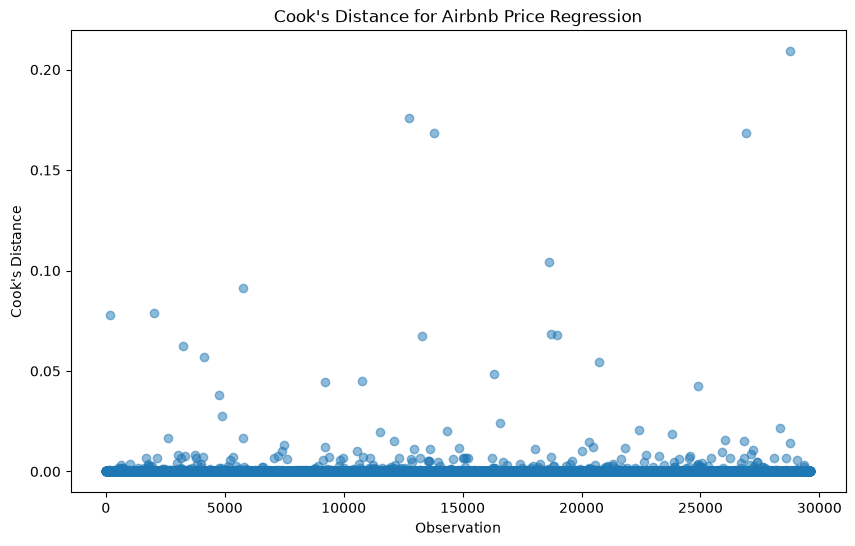

In [28]:
plt.figure(figsize=(10, 6))

plt.scatter(
    range(len(cooks_d)),
    cooks_d,
    alpha=0.5
)

plt.xlabel("Observation")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance for Airbnb Price Regression")
plt.show()

In [29]:
n = len(df_ml)
k = X.shape[1]  # number of predictors including intercept

threshold_1 = 4 / n              # common simple rule
threshold_2 = 4 / (n - k - 1)    # adjusted version

influential_points = df_ml[df_ml['cooks_d'] > threshold_1]
influential_points

,host_is_superhost,neighbourhood_cleansed,latitude,longitude,property_type,accommodates,bathrooms,bedrooms,beds,price,...,availability_365,instant_bookable,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room,neighbourhood_group_cleansed_City of Los Angeles,neighbourhood_group_cleansed_Other Cities,neighbourhood_group_cleansed_Unincorporated Areas,cooks_d
30,0,23,34.122840,-118.401500,26,10,4.5,4.0,4.0,2600.0,...,365,1,True,False,False,False,True,False,False,0.000203
132,0,63,34.094056,-118.292399,69,4,1.0,1.0,2.0,249.0,...,325,1,False,True,False,False,True,False,False,0.000302
144,0,52,34.002877,-118.410281,80,2,6.0,1.0,1.0,108.0,...,362,1,False,False,False,True,False,True,False,0.000957
160,1,216,34.183280,-118.527700,26,10,8.0,6.0,6.0,3500.0,...,365,0,True,False,False,False,True,False,False,0.000512
166,0,19,34.104716,-118.449982,17,16,13.0,9.0,9.0,14700.0,...,345,0,True,False,False,False,True,False,False,0.078030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29344,0,25,34.096620,-118.397850,17,12,6.5,6.0,6.0,6500.0,...,262,0,True,False,False,False,False,True,False,0.003022
29359,0,225,34.371351,-118.564297,4,10,2.0,10.0,10.0,2400.0,...,364,1,True,False,False,False,False,False,True,0.002466
29378,0,110,34.036366,-118.310746,17,12,8.0,10.0,10.0,600.0,...,270,0,True,False,False,False,True,False,False,0.000783
29449,0,220,33.820740,-118.322630,69,2,1.0,1.0,1.0,186.0,...,117,1,False,True,False,False,False,True,False,0.000528


In [30]:
influential_with_data = df_cleaned.join(
    influential_points[["cooks_d"]],
    how="inner"
)

In [31]:
columns_to_include = [
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'price', 'minimum_nights', 'price_per_night',
    'cooks_d'
]

influential_with_data = influential_with_data[columns_to_include]

In [32]:
influential_with_data.sort_values(by = 'cooks_d').tail(20)

,neighbourhood_cleansed,neighbourhood_group_cleansed,property_type,room_type,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,price_per_night,cooks_d
4902,Avalon,Other Cities,Entire home,Entire home/apt,6,2.0,2.0,2.0,550.0,1,550.000000,0.027531
4774,South Whittier,Unincorporated Areas,Entire home,Entire home/apt,9,2.0,4.0,5.0,270.0,2,135.000000,0.038001
24890,Highland Park,City of Los Angeles,Entire rental unit,Entire home/apt,4,1.0,2.0,2.0,111.0,30,3.700000,0.042450
9210,West Hollywood,Other Cities,Entire home,Entire home/apt,4,2.0,2.0,2.0,499.0,30,16.633333,0.044315
10772,Beverly Grove,City of Los Angeles,Entire rental unit,Entire home/apt,2,1.0,1.0,1.0,180.0,1,180.000000,0.045007
16337,Rowland Heights,Unincorporated Areas,Entire home,Entire home/apt,5,1.0,2.0,2.0,122.0,3,40.666667,0.048692
20719,Pasadena,Other Cities,Private room in home,Private room,2,1.5,1.0,1.0,10.0,1,10.000000,0.054424
4110,Westwood,City of Los Angeles,Entire rental unit,Entire home/apt,5,2.0,2.0,2.0,185.0,30,6.166667,0.057177
3260,Hollywood,City of Los Angeles,Entire condo,Entire home/apt,4,1.0,1.0,1.0,200.0,30,6.666667,0.062464
13288,Pico-Robertson,City of Los Angeles,Entire rental unit,Entire home/apt,2,1.0,1.0,2.0,120.0,1,120.000000,0.067483


C:\Users\YapJack\AppData\Local\Temp\ipykernel_32580\3649357791.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(influential_with_data["price"].dropna(), vert=False)


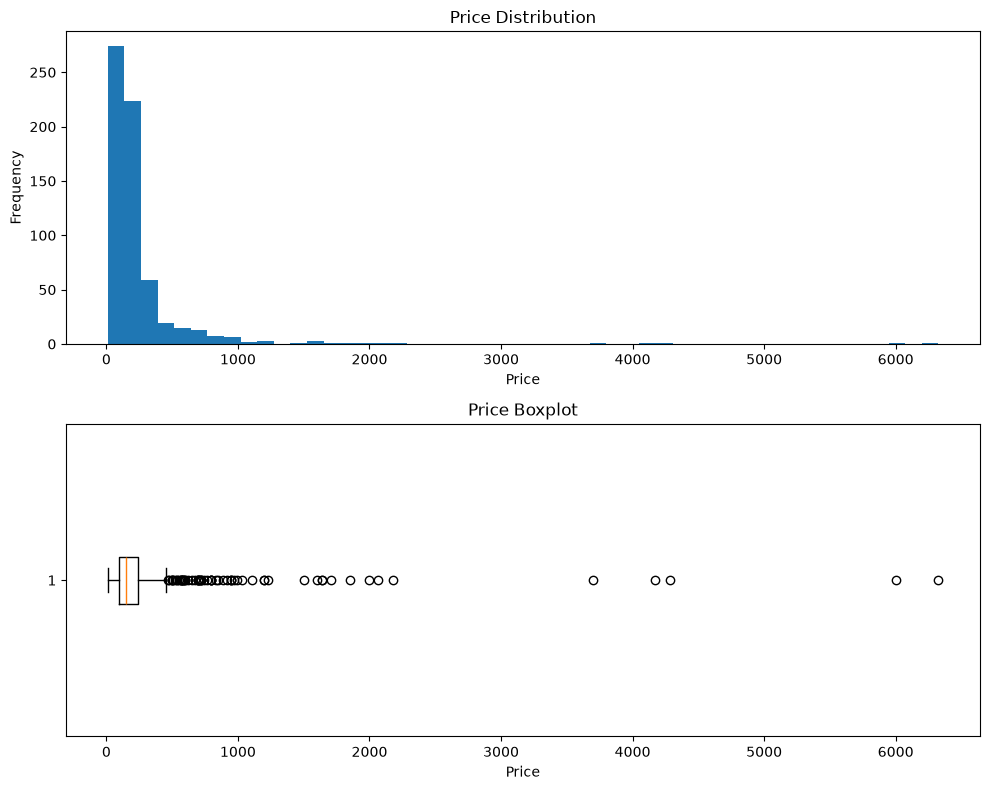

In [33]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Histogram
axes[0].hist(influential_with_data["price"], bins=50)
axes[0].set_title("Price Distribution")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Frequency")

# Boxplot
axes[1].boxplot(influential_with_data["price"].dropna(), vert=False)
axes[1].set_title("Price Boxplot")
axes[1].set_xlabel("Price")

plt.tight_layout()
plt.show()

In [34]:
for col in ["property_type", "neighbourhood_cleansed"]:
    df1_categories = set(df_ml[col].dropna().unique())
    df2_categories = set(df_cleaned_test[col].dropna().unique())

    unseen = df2_categories - df1_categories

    if unseen:
        print(f"{col}: ❌ Categories in df2 but not df1:")
        print(unseen)
    else:
        print(f"{col}: ✅ All df2 categories exist in df1")

property_type: ✅ All df2 categories exist in df1
neighbourhood_cleansed: ✅ All df2 categories exist in df1


In [35]:
df_cleaned_no_influential = df_ml.drop(
    index=influential_with_data.index
)
df_cleaned_no_influential.to_csv('../data/influential_cleaned_train_listing_ml.csv', index = False)